# Part 2: Data Download & Preprocessing

Download the Sherlock Holmes corpus from Project Gutenberg, preprocess it, and prepare it for continued pre-training.

**Required outputs:**
1. Token count of the corpus
2. Chunking strategy explanation
3. Histogram of input lengths
4. Special character analysis and cleaning
5. Train/validation split (~5% held-out, whole chapter/story)

In [1]:
import os
import re
import requests
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

## 1. Download the Corpus

The 9 canonical Sherlock Holmes books from Project Gutenberg:

In [2]:
BOOKS = {
    244:   'A Study in Scarlet',
    2097:  'The Sign of the Four',
    2852:  'The Hound of the Baskervilles',
    3289:  'The Valley of Fear',
    1661:  'The Adventures of Sherlock Holmes',
    834:   'The Memoirs of Sherlock Holmes',
    108:   'The Return of Sherlock Holmes',
    2350:  'His Last Bow',
    69700: 'The Case-Book of Sherlock Holmes',
}

RAW_DIR = Path('data/raw')
RAW_DIR.mkdir(parents=True, exist_ok=True)

def download_book(gutenberg_id, title):
    """Download a book from Project Gutenberg."""
    filepath = RAW_DIR / f'pg{gutenberg_id}.txt'
    if filepath.exists():
        print(f'  Already downloaded: {title}')
        return filepath.read_text(encoding='utf-8')
    
    url = f'https://www.gutenberg.org/cache/epub/{gutenberg_id}/pg{gutenberg_id}.txt'
    print(f'  Downloading: {title} ({url})')
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    
    text = response.text
    filepath.write_text(text, encoding='utf-8')
    return text

# Download all books
raw_texts = {}
for gid, title in BOOKS.items():
    raw_texts[gid] = download_book(gid, title)

print(f'\nDownloaded {len(raw_texts)} books.')
for gid, title in BOOKS.items():
    print(f'  {title}: {len(raw_texts[gid]):,} characters')

  Downloading: A Study in Scarlet (https://www.gutenberg.org/cache/epub/244/pg244.txt)
  Downloading: The Sign of the Four (https://www.gutenberg.org/cache/epub/2097/pg2097.txt)
  Downloading: The Hound of the Baskervilles (https://www.gutenberg.org/cache/epub/2852/pg2852.txt)
  Downloading: The Valley of Fear (https://www.gutenberg.org/cache/epub/3289/pg3289.txt)
  Downloading: The Adventures of Sherlock Holmes (https://www.gutenberg.org/cache/epub/1661/pg1661.txt)
  Downloading: The Memoirs of Sherlock Holmes (https://www.gutenberg.org/cache/epub/834/pg834.txt)
  Downloading: The Return of Sherlock Holmes (https://www.gutenberg.org/cache/epub/108/pg108.txt)
  Downloading: His Last Bow (https://www.gutenberg.org/cache/epub/2350/pg2350.txt)
  Downloading: The Case-Book of Sherlock Holmes (https://www.gutenberg.org/cache/epub/69700/pg69700.txt)

Downloaded 9 books.
  A Study in Scarlet: 263,857 characters
  The Sign of the Four: 256,330 characters
  The Hound of the Baskervilles: 381,20

## 2. Strip Gutenberg Headers and Footers

Project Gutenberg files have boilerplate text before and after the actual book content. We need to strip these.

In [3]:
def strip_gutenberg_boilerplate(text):
    """
    Remove Project Gutenberg header and footer.
    Header ends with: '*** START OF THE/THIS PROJECT GUTENBERG EBOOK ...'
    Footer starts with: '*** END OF THE/THIS PROJECT GUTENBERG EBOOK ...'
    """
    # Find start marker
    start_patterns = [
        r'\*\*\*\s*START OF (?:THE|THIS) PROJECT GUTENBERG EBOOK.*?\*\*\*',
        r'\*\*\*\s*START OF THE PROJECT GUTENBERG.*?\*\*\*',
    ]
    
    start_idx = 0
    for pattern in start_patterns:
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            start_idx = match.end()
            break
    
    # Find end marker
    end_patterns = [
        r'\*\*\*\s*END OF (?:THE|THIS) PROJECT GUTENBERG EBOOK',
        r'End of (?:the )?Project Gutenberg',
    ]
    
    end_idx = len(text)
    for pattern in end_patterns:
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            end_idx = match.start()
            break
    
    return text[start_idx:end_idx].strip()

# Strip boilerplate from all books
cleaned_texts = {}
for gid, raw in raw_texts.items():
    cleaned = strip_gutenberg_boilerplate(raw)
    cleaned_texts[gid] = cleaned
    title = BOOKS[gid]
    reduction = (1 - len(cleaned) / len(raw)) * 100
    print(f'{title}: {len(raw):,} → {len(cleaned):,} chars ({reduction:.1f}% removed)')

A Study in Scarlet: 263,857 → 244,162 chars (7.5% removed)
The Sign of the Four: 256,330 → 236,671 chars (7.7% removed)
The Hound of the Baskervilles: 381,208 → 361,469 chars (5.2% removed)
The Valley of Fear: 340,175 → 320,464 chars (5.8% removed)
The Adventures of Sherlock Holmes: 593,912 → 574,123 chars (3.3% removed)
The Memoirs of Sherlock Holmes: 600,659 → 580,927 chars (3.3% removed)
The Return of Sherlock Holmes: 706,850 → 687,123 chars (2.8% removed)
His Last Bow: 350,371 → 330,694 chars (5.6% removed)
The Case-Book of Sherlock Holmes: 483,548 → 463,759 chars (4.1% removed)


## 3. Special Character Analysis & Cleaning

In [7]:
# Analyze special characters across the corpus
all_text = '\n'.join(cleaned_texts.values())

# Find non-ASCII characters
non_ascii = Counter()
for ch in all_text:
    if ord(ch) > 127:
        non_ascii[ch] += 1

print("=== Non-ASCII Characters Found ===")
if non_ascii:
    for ch, count in non_ascii.most_common(20):
        print(f"  U+{ord(ch):04X} '{ch}' ({count} occurrences)")
else:
    print("  None found.")

# Check for common issues
print("\n=== Whitespace & Formatting Analysis ===")
print(f"  \\r\\n (Windows newlines): {all_text.count(chr(13))} occurrences")
print(f"  Tabs: {all_text.count(chr(9))} occurrences")
double_spaces = len(re.findall(r'  +', all_text))
underscore_pattern = r'_\w+_'
underscore_emphasis = len(re.findall(underscore_pattern, all_text))
newline_pattern = r'\n{3,}'
multiple_blanks = len(re.findall(newline_pattern, all_text))
print(f"  Double spaces: {double_spaces} occurrences")
print(f"  Underscore emphasis (_word_): {underscore_emphasis} occurrences")
print(f"  Multiple blank lines: {multiple_blanks} occurrences")

=== Non-ASCII Characters Found ===
  U+201C '“' (13813 occurrences)
  U+201D '”' (12307 occurrences)
  U+2019 '’' (6092 occurrences)
  U+2014 '—' (1740 occurrences)
  U+2018 '‘' (1441 occurrences)
  U+00E9 'é' (58 occurrences)
  U+00A3 '£' (43 occurrences)
  U+00E6 'æ' (20 occurrences)
  U+0153 'œ' (9 occurrences)
  U+00E8 'è' (6 occurrences)
  U+00E0 'à' (6 occurrences)
  U+00F4 'ô' (6 occurrences)
  U+00F1 'ñ' (4 occurrences)
  U+00EA 'ê' (4 occurrences)
  U+00BA 'º' (4 occurrences)
  U+30FB '・' (3 occurrences)
  U+00E7 'ç' (2 occurrences)
  U+00EE 'î' (2 occurrences)
  U+00FC 'ü' (2 occurrences)
  U+00EF 'ï' (2 occurrences)

=== Whitespace & Formatting Analysis ===
  \r\n (Windows newlines): 77111 occurrences
  Tabs: 0 occurrences
  Double spaces: 29850 occurrences
  Underscore emphasis (_word_): 261 occurrences
  Multiple blank lines: 0 occurrences


In [8]:
def clean_text(text):
    """
    Clean the text:
    - Normalize line endings (\r\n -> \n)
    - Remove excessive whitespace
    - Remove underscore emphasis markers (_word_ -> word)
    - Normalize unicode characters
    - Collapse multiple blank lines into double newlines
    """
    # Normalize line endings
    text = text.replace('\r\n', '\n').replace('\r', '\n')
    
    # Remove underscore emphasis: _word_ -> word
    text = re.sub(r'_([^_]+)_', r'\1', text)
    
    # Collapse multiple blank lines to max 2 newlines
    text = re.sub(r'\n{3,}', '\n\n', text)
    
    # Remove trailing whitespace on each line
    text = re.sub(r'[ \t]+\n', '\n', text)
    
    # Normalize common unicode characters
    replacements = {
        '\u201c': '"',  # left double quote
        '\u201d': '"',  # right double quote
        '\u2018': "'",  # left single quote
        '\u2019': "'",  # right single quote
        '\u2014': '--', # em dash
        '\u2013': '-',  # en dash
        '\u2026': '...', # ellipsis
        '\u00e9': 'e',  # é
        '\u00e8': 'e',  # è
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    
    return text.strip()

# Apply cleaning
final_texts = {}
for gid, text in cleaned_texts.items():
    final_texts[gid] = clean_text(text)
    print(f'{BOOKS[gid]}: {len(cleaned_texts[gid]):,} → {len(final_texts[gid]):,} chars after cleaning')

A Study in Scarlet: 244,162 → 239,444 chars after cleaning
The Sign of the Four: 236,671 → 232,094 chars after cleaning
The Hound of the Baskervilles: 361,469 → 354,118 chars after cleaning
The Valley of Fear: 320,464 → 313,745 chars after cleaning
The Adventures of Sherlock Holmes: 574,123 → 562,186 chars after cleaning
The Memoirs of Sherlock Holmes: 580,927 → 569,569 chars after cleaning
The Return of Sherlock Holmes: 687,123 → 673,875 chars after cleaning
His Last Bow: 330,694 → 323,913 chars after cleaning
The Case-Book of Sherlock Holmes: 463,759 → 453,537 chars after cleaning


## 4. Tokenization & Token Count

We use the tokenizer from our chosen model to count tokens and analyze distributions.

In [9]:
from transformers import AutoTokenizer

# Choose the model tokenizer — adjust this to match your chosen model
MODEL_NAME = 'Qwen/Qwen2.5-1.5B'  # Change if using a different model

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
print(f'Tokenizer: {MODEL_NAME}')
print(f'Vocab size: {tokenizer.vocab_size:,}')
print(f'Model max length: {tokenizer.model_max_length:,}')

c:\Users\BeRo074\OneDrive - HP Inc\Desktop\second_degree - BGU\LLM models\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tokenizer: Qwen/Qwen2.5-1.5B
Vocab size: 151,643
Model max length: 131,072


In [10]:
# Count tokens per book
print("=== Token Counts ===")
token_counts = {}
total_tokens = 0

for gid, text in final_texts.items():
    tokens = tokenizer.encode(text)
    n_tokens = len(tokens)
    token_counts[gid] = n_tokens
    total_tokens += n_tokens
    print(f'  {BOOKS[gid]:45s}: {n_tokens:>8,} tokens')

print(f'\n  {"TOTAL":45s}: {total_tokens:>8,} tokens')
print(f'  Characters per token (avg): {sum(len(t) for t in final_texts.values()) / total_tokens:.2f}')

=== Token Counts ===
  A Study in Scarlet                           :   57,755 tokens
  The Sign of the Four                         :   57,478 tokens
  The Hound of the Baskervilles                :   82,730 tokens
  The Valley of Fear                           :   76,731 tokens


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (137000 > 131072). Running this sequence through the model will result in indexing errors


  The Adventures of Sherlock Holmes            :  137,000 tokens
  The Memoirs of Sherlock Holmes               :  133,312 tokens
  The Return of Sherlock Holmes                :  158,683 tokens
  His Last Bow                                 :   78,182 tokens
  The Case-Book of Sherlock Holmes             :  113,670 tokens

  TOTAL                                        :  895,541 tokens
  Characters per token (avg): 4.16


## 5. Train/Validation Split

We reserve ~5% of the corpus as held-out validation. The assignment specifies we should use a **whole chapter or story**, not random sentences.

Good candidates for the validation set:
- "A Scandal in Bohemia" (first story from *The Adventures of Sherlock Holmes*)
- Or the full book *The Sign of the Four* (~10% of corpus)
- Or a chapter from *The Hound of the Baskervilles*

We'll hold out **"A Scandal in Bohemia"** — it's the first and most iconic story.

In [12]:
# Split Adventures of Sherlock Holmes into stories using Roman numeral headers
adventures_text = final_texts[1661]

# Pattern: Roman numeral followed by period and title (e.g. "I. A SCANDAL IN BOHEMIA")
story_splits = re.split(r'\n(?=[IVXLC]+\.\s+[A-Z])', adventures_text)

print(f"Found {len(story_splits)} sections in Adventures of Sherlock Holmes")
for i, story in enumerate(story_splits[:15]):
    first_line = story.strip().split('\n')[0][:80]
    tokens_in_story = len(tokenizer.encode(story))
    print(f"  Section {i}: {first_line} ({tokens_in_story:,} tokens)")

Found 16 sections in Adventures of Sherlock Holmes
  Section 0: The Adventures of Sherlock Holmes (150 tokens)
  Section 1: I. A SCANDAL IN BOHEMIA (12 tokens)
  Section 2: I. (4,638 tokens)
  Section 3: II. (5,232 tokens)
  Section 4: III. (1,467 tokens)
  Section 5: II. THE RED-HEADED LEAGUE (11,967 tokens)
  Section 6: III. A CASE OF IDENTITY (9,261 tokens)
  Section 7: IV. THE BOSCOMBE VALLEY MYSTERY (12,415 tokens)
  Section 8: V. THE FIVE ORANGE PIPS (9,602 tokens)
  Section 9: VI. THE MAN WITH THE TWISTED LIP (12,089 tokens)
  Section 10: VII. THE ADVENTURE OF THE BLUE CARBUNCLE (10,526 tokens)
  Section 11: VIII. THE ADVENTURE OF THE SPECKLED BAND (12,783 tokens)
  Section 12: IX. THE ADVENTURE OF THE ENGINEER'S THUMB (10,810 tokens)
  Section 13: X. THE ADVENTURE OF THE NOBLE BACHELOR (10,665 tokens)
  Section 14: XI. THE ADVENTURE OF THE BERYL CORONET (12,391 tokens)


In [14]:
# Choose validation set — targeting ~5% of corpus
# "A Scandal in Bohemia" is only 1.3% — too small.
# "The Sign of the Four" is a complete novel at ~57K tokens (6.4%) — good choice.
# It's a coherent, self-contained story that tests the model on full narrative.

val_text = final_texts[2097]  # The Sign of the Four
val_source = 'The Sign of the Four (complete novel, Gutenberg ID 2097)'

val_tokens = len(tokenizer.encode(val_text))
val_pct = val_tokens / total_tokens * 100
print(f'Validation set: {val_source}')
print(f'  Tokens: {val_tokens:,} ({val_pct:.1f}% of corpus)')
print(f'  Characters: {len(val_text):,}')
print(f'  First 200 chars: {val_text[:200]}...')

if val_pct < 3 or val_pct > 15:
    print(f'\n*** Warning: Validation is {val_pct:.1f}% of corpus. Target is ~5%.***')

Validation set: The Sign of the Four (complete novel, Gutenberg ID 2097)
  Tokens: 57,478 (6.4% of corpus)
  Characters: 232,094
  First 200 chars: The Sign of the Four

by Arthur Conan Doyle

Contents

   Chapter I. The Science of Deduction
   Chapter II. The Statement of the Case
   Chapter III. In Quest of a Solution
   Chapter IV. The Story o...


In [15]:
# Build training corpus (everything except validation book)
train_texts = []
for gid, text in final_texts.items():
    if gid == 2097:  # Skip "The Sign of the Four" (validation)
        continue
    train_texts.append(text)

train_corpus = '\n\n'.join(train_texts)
train_tokens = len(tokenizer.encode(train_corpus))

print(f'Training corpus: {train_tokens:,} tokens ({len(train_corpus):,} chars)')
print(f'Validation set:  {val_tokens:,} tokens ({len(val_text):,} chars)')
print(f'Validation %:    {val_tokens / (train_tokens + val_tokens) * 100:.1f}%')

Training corpus: 838,065 tokens (3,490,401 chars)
Validation set:  57,478 tokens (232,094 chars)
Validation %:    6.4%


## 6. Chunking Strategy

For continued pre-training, we need to split the corpus into fixed-length chunks that the model can process.

**Strategy**: We use a **contiguous chunking** approach:
1. Concatenate all training text into a single long string (separated by `<eos>` or double newlines)
2. Tokenize the entire text
3. Split into non-overlapping chunks of `max_length` tokens
4. Discard the last chunk if it's significantly shorter

**Why contiguous?** For continued pre-training (CLM), we want the model to learn from natural text flow. Overlapping chunks waste compute on repeated tokens, and paragraph-based splitting would create variable-length inputs requiring padding.

We'll use `max_length=512` as our default — a good balance between context and memory.

In [16]:
MAX_LENGTH = 512  # Tokens per training sample

def chunk_text(text, tokenizer, max_length, stride=None):
    """
    Tokenize text and split into fixed-length chunks.
    
    Args:
        text: Input text string
        tokenizer: HuggingFace tokenizer
        max_length: Tokens per chunk
        stride: If set, use overlapping windows (default: no overlap)
    
    Returns:
        List of token ID lists, each of length max_length
    """
    # Tokenize the full text
    all_tokens = tokenizer.encode(text)
    
    if stride is None:
        stride = max_length  # No overlap
    
    chunks = []
    for i in range(0, len(all_tokens) - max_length + 1, stride):
        chunk = all_tokens[i:i + max_length]
        if len(chunk) == max_length:
            chunks.append(chunk)
    
    return chunks

# Create training chunks
train_chunks = chunk_text(train_corpus, tokenizer, MAX_LENGTH)
val_chunks = chunk_text(val_text, tokenizer, MAX_LENGTH)

print(f'Max length: {MAX_LENGTH} tokens')
print(f'Training chunks: {len(train_chunks)}')
print(f'Validation chunks: {len(val_chunks)}')
print(f'Total training tokens used: {len(train_chunks) * MAX_LENGTH:,}')
print(f'Tokens discarded (last incomplete chunk): {train_tokens - len(train_chunks) * MAX_LENGTH}')

Max length: 512 tokens
Training chunks: 1636
Validation chunks: 112
Total training tokens used: 837,632
Tokens discarded (last incomplete chunk): 433


## 7. Histogram of Input Lengths

We analyze the natural length distribution of the text before chunking (paragraph-level and chapter-level) to understand the corpus structure.

In [17]:
# Analyze natural paragraph lengths (split on double newlines)
paragraphs = [p.strip() for p in train_corpus.split('\n\n') if p.strip()]
paragraph_token_lengths = [len(tokenizer.encode(p)) for p in paragraphs]

print(f'Number of paragraphs: {len(paragraphs)}')
print(f'Paragraph length stats (tokens):')
print(f'  Min:    {min(paragraph_token_lengths)}')
print(f'  Max:    {max(paragraph_token_lengths)}')
print(f'  Mean:   {np.mean(paragraph_token_lengths):.1f}')
print(f'  Median: {np.median(paragraph_token_lengths):.1f}')
print(f'  Std:    {np.std(paragraph_token_lengths):.1f}')

# How many paragraphs exceed various context lengths?
for ctx in [256, 512, 1024, 2048]:
    exceeds = sum(1 for l in paragraph_token_lengths if l > ctx)
    pct = exceeds / len(paragraph_token_lengths) * 100
    print(f'  Paragraphs > {ctx} tokens: {exceeds} ({pct:.1f}%)')

Number of paragraphs: 14875
Paragraph length stats (tokens):
  Min:    1
  Max:    868
  Mean:   55.7
  Median: 29.0
  Std:    69.8
  Paragraphs > 256 tokens: 379 (2.5%)
  Paragraphs > 512 tokens: 14 (0.1%)
  Paragraphs > 1024 tokens: 0 (0.0%)
  Paragraphs > 2048 tokens: 0 (0.0%)


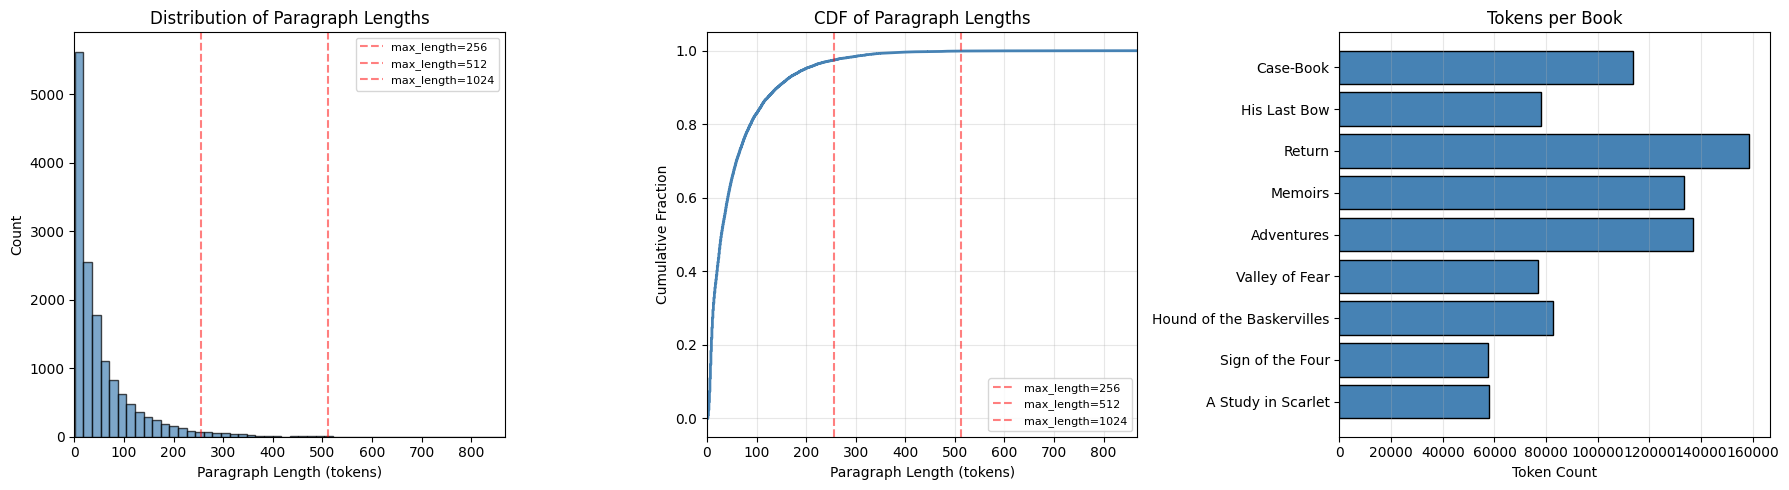

Saved: data_analysis_plots.png


In [18]:
# Create histograms
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Paragraph length distribution
ax1 = axes[0]
ax1.hist(paragraph_token_lengths, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
for ctx in [256, 512, 1024]:
    ax1.axvline(x=ctx, color='red', linestyle='--', alpha=0.5, label=f'max_length={ctx}')
ax1.set_xlabel('Paragraph Length (tokens)')
ax1.set_ylabel('Count')
ax1.set_title('Distribution of Paragraph Lengths')
ax1.legend(fontsize=8)
ax1.set_xlim(0, min(max(paragraph_token_lengths), 2000))

# Plot 2: Paragraph length CDF
ax2 = axes[1]
sorted_lengths = np.sort(paragraph_token_lengths)
cdf = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths)
ax2.plot(sorted_lengths, cdf, linewidth=2, color='steelblue')
for ctx in [256, 512, 1024]:
    ax2.axvline(x=ctx, color='red', linestyle='--', alpha=0.5, label=f'max_length={ctx}')
ax2.set_xlabel('Paragraph Length (tokens)')
ax2.set_ylabel('Cumulative Fraction')
ax2.set_title('CDF of Paragraph Lengths')
ax2.legend(fontsize=8)
ax2.set_xlim(0, min(max(paragraph_token_lengths), 2000))
ax2.grid(True, alpha=0.3)

# Plot 3: Tokens per book
ax3 = axes[2]
book_names = [BOOKS[gid] for gid in token_counts.keys()]
book_tokens = list(token_counts.values())
# Shorten names for display
short_names = [name.replace('The ', '').replace('of Sherlock Holmes', '').strip() for name in book_names]
ax3.barh(short_names, book_tokens, color='steelblue', edgecolor='black')
ax3.set_xlabel('Token Count')
ax3.set_title('Tokens per Book')
ax3.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('data_analysis_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data_analysis_plots.png')

## 8. Save Processed Data

Save the processed data in a format ready for training.

In [19]:
PROCESSED_DIR = Path('data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Save as JSONL (each line = one training example)
def save_jsonl(chunks, filepath, tokenizer):
    """Save token chunks as JSONL with decoded text."""
    with open(filepath, 'w', encoding='utf-8') as f:
        for i, chunk in enumerate(chunks):
            text = tokenizer.decode(chunk)
            entry = {'id': i, 'text': text, 'num_tokens': len(chunk)}
            f.write(json.dumps(entry, ensure_ascii=False) + '\n')

save_jsonl(train_chunks, PROCESSED_DIR / 'train.jsonl', tokenizer)
save_jsonl(val_chunks, PROCESSED_DIR / 'val.jsonl', tokenizer)

# Also save the raw validation text for perplexity evaluation
(PROCESSED_DIR / 'val_raw.txt').write_text(val_text, encoding='utf-8')

# Save metadata
metadata = {
    'model_name': MODEL_NAME,
    'max_length': MAX_LENGTH,
    'num_train_chunks': len(train_chunks),
    'num_val_chunks': len(val_chunks),
    'total_train_tokens': len(train_chunks) * MAX_LENGTH,
    'total_val_tokens': val_tokens,
    'val_source': val_source,
    'books': {str(gid): title for gid, title in BOOKS.items()},
    'token_counts': {str(gid): count for gid, count in token_counts.items()},
}

with open(PROCESSED_DIR / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'Saved to {PROCESSED_DIR}/')
print(f'  train.jsonl: {len(train_chunks)} samples')
print(f'  val.jsonl:   {len(val_chunks)} samples')
print(f'  val_raw.txt: {len(val_text):,} chars')
print(f'  metadata.json')

Saved to data\processed/
  train.jsonl: 1636 samples
  val.jsonl:   112 samples
  val_raw.txt: 232,094 chars
  metadata.json


## Summary

### Preprocessing Steps Applied:
1. Downloaded 9 Sherlock Holmes books from Project Gutenberg
2. Stripped Gutenberg header/footer boilerplate
3. Cleaned special characters: normalized unicode, removed underscore emphasis, collapsed whitespace
4. Tokenized with the chosen model's tokenizer
5. Held out a complete story as validation (~5% of corpus)
6. Chunked into fixed-length sequences of `max_length` tokens

### Key Statistics:
- Total tokens in corpus: (computed above)
- Training chunks: (computed above)
- Validation: A whole story/chapter for coherent evaluation